# electrification cement NPV simulation

Run the electrification cement Monte Carlo simulation and visualize the resulting NPV distribution.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_technology_npv,
)


In [2]:
TECHNOLOGY = 'electrification'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_cement_technology_npv(
    technology=TECHNOLOGY,
    size=SAMPLE_SIZE,
    rng=rng,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,electricity_consumption_mwh_per_t,...,annual_variable_opex_eur,annual_fuel_cost_eur,annual_electricity_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_t,npv_eur_per_t,npv_million_eur_per_t,coal_price_eur_per_mwh_th
0,0,electrification,absolute,not_applicable,1000000.0,241.076023,25.127351,7.392042,0.0,0.947933,...,7.392042e+06,0.0,1.702566e+08,3.119745e+07,-8.397344e+07,-1.137474e+09,25000000.0,-45.498947,-0.000045,13.578016
1,1,electrification,absolute,not_applicable,1000000.0,207.162361,25.340866,7.356204,0.0,0.941142,...,7.356204e+06,0.0,1.533739e+08,3.512308e+07,-7.119410e+07,-9.671434e+08,25000000.0,-38.685737,-0.000039,9.132512
2,2,electrification,absolute,not_applicable,1000000.0,253.395966,20.085515,9.302543,0.0,0.976664,...,9.302543e+06,0.0,8.880554e+07,3.189752e+07,-9.112100e+04,-2.543687e+08,25000000.0,-10.174747,-0.000010,11.974056
3,3,electrification,absolute,not_applicable,1000000.0,231.820626,17.751614,7.963446,0.0,0.974067,...,7.963446e+06,0.0,1.987246e+08,3.381131e+07,-1.082510e+08,-1.387376e+09,25000000.0,-55.495042,-0.000055,10.982182
4,4,electrification,absolute,not_applicable,1000000.0,171.054405,22.067768,8.710812,0.0,0.974881,...,8.710812e+06,0.0,1.732033e+08,3.118267e+07,-8.516453e+07,-1.080167e+09,25000000.0,-43.206670,-0.000043,11.398602


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_t = results["npv_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/t"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/t
count,100000.000000,100000.000000
mean,-1115.579303,-44.623172
std,372.882809,14.915312
min,-2072.047734,-82.881909
5%,-1682.481734,-67.299269
50%,-1140.810313,-45.632413
95%,-466.451704,-18.658068
max,47.957917,1.918317


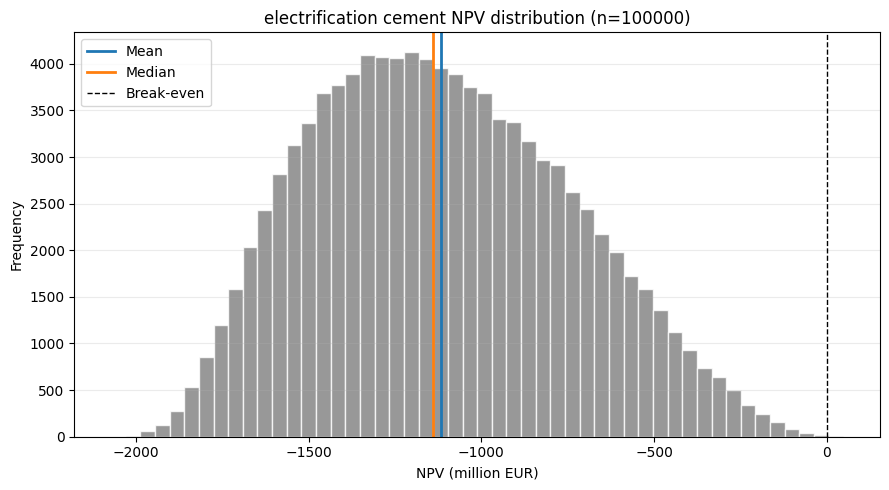

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrification cement NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


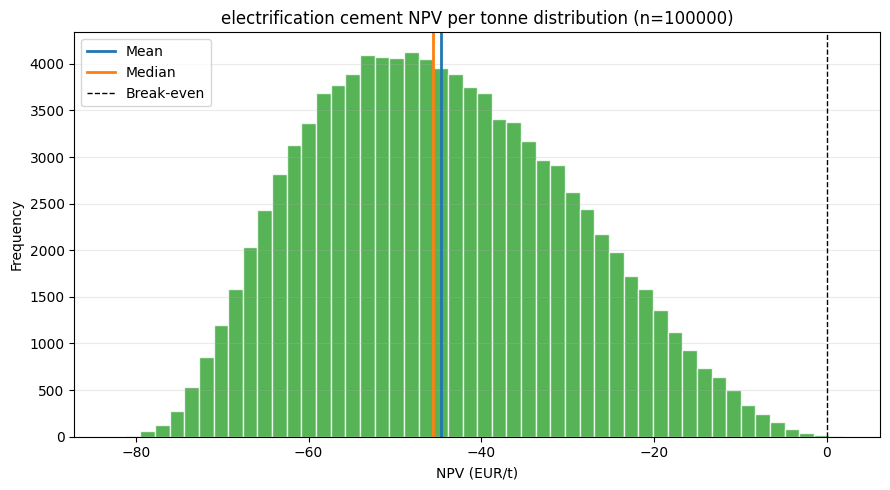

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrification cement NPV per tonne distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/t)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           19.995628
annual_variable_opex_eur         7.801809
annual_fuel_cost_eur             0.000000
annual_electricity_cost_eur    174.610546
annual_emissions_cost_eur       31.983186
annual_net_cash_flow_eur       -84.391169
Name: Mean annual value, million EUR, dtype: float64